In [1]:
"""
# 🏦 CreditSense: Loan Risk Assessment — Baseline Template

## Your Two Tasks

**Task A — Classification:** Predict `RiskTier` (0 to 4)
- 0 = Very Low Risk → 4 = Very High Risk

**Task B — Regression:** Predict `InterestRate` (%)
- Annual percentage rate offered to the applicant
- Range: 4.99% (best) to 35.99% (worst)

## What this baseline does
- Loads and preprocesses the data
- Trains a **Logistic Regression** for Task A (~53% accuracy)
- Trains a **Linear Regression** for Task B (R² ~0.50)
- Saves a submission file

**Your goal: beat both baselines!**
"""

'\n# 🏦 CreditSense: Loan Risk Assessment — Baseline Template\n\n## Your Two Tasks\n\n**Task A — Classification:** Predict `RiskTier` (0 to 4)\n- 0 = Very Low Risk → 4 = Very High Risk\n\n**Task B — Regression:** Predict `InterestRate` (%)\n- Annual percentage rate offered to the applicant\n- Range: 4.99% (best) to 35.99% (worst)\n\n## What this baseline does\n- Loads and preprocesses the data\n- Trains a **Logistic Regression** for Task A (~53% accuracy)\n- Trains a **Linear Regression** for Task B (R² ~0.50)\n- Saves a submission file\n\n**Your goal: beat both baselines!**\n'

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, classification_report, f1_score,
                             r2_score, mean_squared_error)
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")


Libraries loaded!


In [3]:
train = pd.read_csv('creditsense-ai1215/credit_train.csv')

X     = train.drop(['RiskTier', 'InterestRate'], axis=1)
y_cls = train['RiskTier']
y_reg = train['InterestRate']

print(f"Dataset shape: {X.shape}")
print()
print("Task A — RiskTier distribution:")
print(y_cls.value_counts().sort_index())
print()
print("Task B — InterestRate summary:")
print(y_reg.describe().round(2))

# TODO: Explore the data further
# X.isnull().sum()       ← check missing values
# X.describe()           ← check feature ranges
# X.dtypes               ← check feature types


Dataset shape: (35000, 55)

Task A — RiskTier distribution:
RiskTier
0    6724
1    7283
2    6998
3    6812
4    7183
Name: count, dtype: int64

Task B — InterestRate summary:
count    35000.00
mean         7.31
std          4.19
min          4.99
25%          4.99
50%          6.08
75%          7.94
max         35.99
Name: InterestRate, dtype: float64


In [4]:
TASK_A_ZERO_FILL_COLS = [
    'StudentLoanOutstandingBalance',
    'MortgageOutstandingBalance',
    'PropertyValue',
    'InvestmentPortfolioValue',
    'VehicleValue',
    'AutoLoanOutstandingBalance',
    'SecondaryMonthlyIncome',
    'CollateralValue',
]

TASK_A_MONEY_CLIP_COLS = [
    'AnnualIncome',
    'MonthlyGrossIncome',
    'SecondaryMonthlyIncome',
    'TotalMonthlyIncome',
    'SavingsBalance',
    'CheckingBalance',
    'InvestmentPortfolioValue',
    'PropertyValue',
    'VehicleValue',
    'TotalAssets',
    'MortgageOutstandingBalance',
    'AutoLoanOutstandingBalance',
    'StudentLoanOutstandingBalance',
    'TotalCreditLimit',
    'RequestedLoanAmount',
    'CollateralValue',
    'MonthlyPaymentEstimate',
]
TASK_A_RATIO_CLIP_COLS = ['LoanToIncomeRatio', 'PaymentToIncomeRatio']
TASK_A_LOG_COLS = TASK_A_MONEY_CLIP_COLS.copy()


def _fit_tabular_preprocessor(X_train_raw, *, zero_fill_cols, clip_cols, log_cols):
    X_train_raw = X_train_raw.copy()

    base_cols = X_train_raw.columns.tolist()
    num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()
    missing_flag_cols = [col for col in base_cols if X_train_raw[col].isna().any()]

    zero_fill_cols = [col for col in zero_fill_cols if col in num_cols]
    median_fill_map = {
        col: float(X_train_raw[col].median())
        for col in num_cols if col not in zero_fill_cols
    }

    clip_map = {}
    for col in clip_cols:
        if col not in num_cols:
            continue
        non_null = X_train_raw[col].dropna()
        clip_map[col] = float(non_null.quantile(0.99)) if not non_null.empty else 0.0

    prep = {
        'cat_cols': cat_cols,
        'num_cols': num_cols,
        'missing_flag_cols': missing_flag_cols,
        'zero_fill_cols': zero_fill_cols,
        'median_fill_map': median_fill_map,
        'clip_map': clip_map,
        'log_cols': [col for col in log_cols if col in num_cols],
    }

    transformed_train = _transform_tabular(X_train_raw, prep, align=False)
    prep['feature_columns'] = transformed_train.columns.tolist()
    return prep


def _transform_tabular(X_raw, prep, align=True):
    working = X_raw.copy()

    for col in prep['missing_flag_cols']:
        working[f'{col}_is_missing'] = working[col].isna().astype(np.int8)

    for col in prep['cat_cols']:
        working[col] = working[col].fillna('Missing').astype(str)

    for col in prep['zero_fill_cols']:
        working[col] = working[col].fillna(0.0)

    for col, med in prep['median_fill_map'].items():
        working[col] = working[col].fillna(med)

    for col, upper in prep['clip_map'].items():
        working[col] = working[col].clip(upper=upper)

    for col in prep['log_cols']:
        working[col] = np.log1p(working[col])

    numeric_frame = working[prep['num_cols']].apply(pd.to_numeric)
    missing_cols = [f'{col}_is_missing' for col in prep['missing_flag_cols']]
    missing_frame = (
        working[missing_cols].astype(np.int8)
        if missing_cols else pd.DataFrame(index=working.index)
    )
    cat_frame = pd.get_dummies(
        working[prep['cat_cols']],
        prefix=prep['cat_cols'],
        prefix_sep='__',
        drop_first=False,
        dtype=np.int8,
    )

    transformed = pd.concat([numeric_frame, missing_frame, cat_frame], axis=1)
    transformed = transformed.fillna(0)

    if align and 'feature_columns' in prep:
        transformed = transformed.reindex(columns=prep['feature_columns'], fill_value=0)

    return transformed


def fit_task_a_preprocessor(X_train_raw):
    return _fit_tabular_preprocessor(
        X_train_raw,
        zero_fill_cols=TASK_A_ZERO_FILL_COLS,
        clip_cols=TASK_A_MONEY_CLIP_COLS + TASK_A_RATIO_CLIP_COLS,
        log_cols=TASK_A_LOG_COLS,
    )


def transform_task_a(X_raw, prep):
    transformed = _transform_tabular(X_raw, prep, align=True)
    return transformed.reindex(columns=prep['feature_columns'], fill_value=0)


def fit_task_b_preprocessor(X_train_raw):
    return _fit_tabular_preprocessor(
        X_train_raw,
        zero_fill_cols=TASK_A_ZERO_FILL_COLS,
        clip_cols=TASK_A_MONEY_CLIP_COLS + TASK_A_RATIO_CLIP_COLS,
        log_cols=TASK_A_LOG_COLS,
    )


def transform_task_b(X_raw, prep):
    transformed = _transform_tabular(X_raw, prep, align=True)
    return transformed.reindex(columns=prep['feature_columns'], fill_value=0)


def fit_task_a_baseline_preprocessor(X_train_raw):
    X_train_raw = X_train_raw.copy()

    base_cols = X_train_raw.columns.tolist()
    num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()
    missing_flag_cols = [col for col in base_cols if X_train_raw[col].isna().any()]

    median_fill_map = {col: float(X_train_raw[col].median()) for col in num_cols}
    cat_fill_map = {}
    cat_value_map = {}
    for col in cat_cols:
        mode_series = X_train_raw[col].mode(dropna=True)
        fill_value = mode_series.iloc[0] if not mode_series.empty else 'Unknown'
        cat_fill_map[col] = str(fill_value)

        filled = X_train_raw[col].fillna(fill_value).astype(str)
        cat_value_map[col] = {value: idx for idx, value in enumerate(pd.Index(filled.unique()))}

    prep = {
        'num_cols': num_cols,
        'cat_cols': cat_cols,
        'missing_flag_cols': missing_flag_cols,
        'median_fill_map': median_fill_map,
        'cat_fill_map': cat_fill_map,
        'cat_value_map': cat_value_map,
    }

    transformed_train = transform_task_a_baseline(X_train_raw, prep, align=False)
    prep['feature_columns'] = transformed_train.columns.tolist()
    return prep


def transform_task_a_baseline(X_raw, prep, align=True):
    working = X_raw.copy()

    for col in prep['missing_flag_cols']:
        working[f'{col}_is_missing'] = working[col].isna().astype(np.int8)

    for col, med in prep['median_fill_map'].items():
        working[col] = working[col].fillna(med)

    for col in prep['cat_cols']:
        working[col] = working[col].fillna(prep['cat_fill_map'][col]).astype(str)
        working[col] = working[col].map(prep['cat_value_map'][col]).fillna(-1).astype(int)

    feature_cols = (
        prep['num_cols'] +
        [f'{col}_is_missing' for col in prep['missing_flag_cols']] +
        prep['cat_cols']
    )
    transformed = working[feature_cols].copy().fillna(0)

    if align and 'feature_columns' in prep:
        transformed = transformed.reindex(columns=prep['feature_columns'], fill_value=0)

    return transformed


eda_task_a_prep = fit_task_a_preprocessor(X)
X_processed = transform_task_a(X, eda_task_a_prep)
print()
print(f"Task A EDA matrix — shape: {X_processed.shape} | missing: {X_processed.isnull().sum().sum()}")



Task A EDA matrix — shape: (35000, 115) | missing: 0


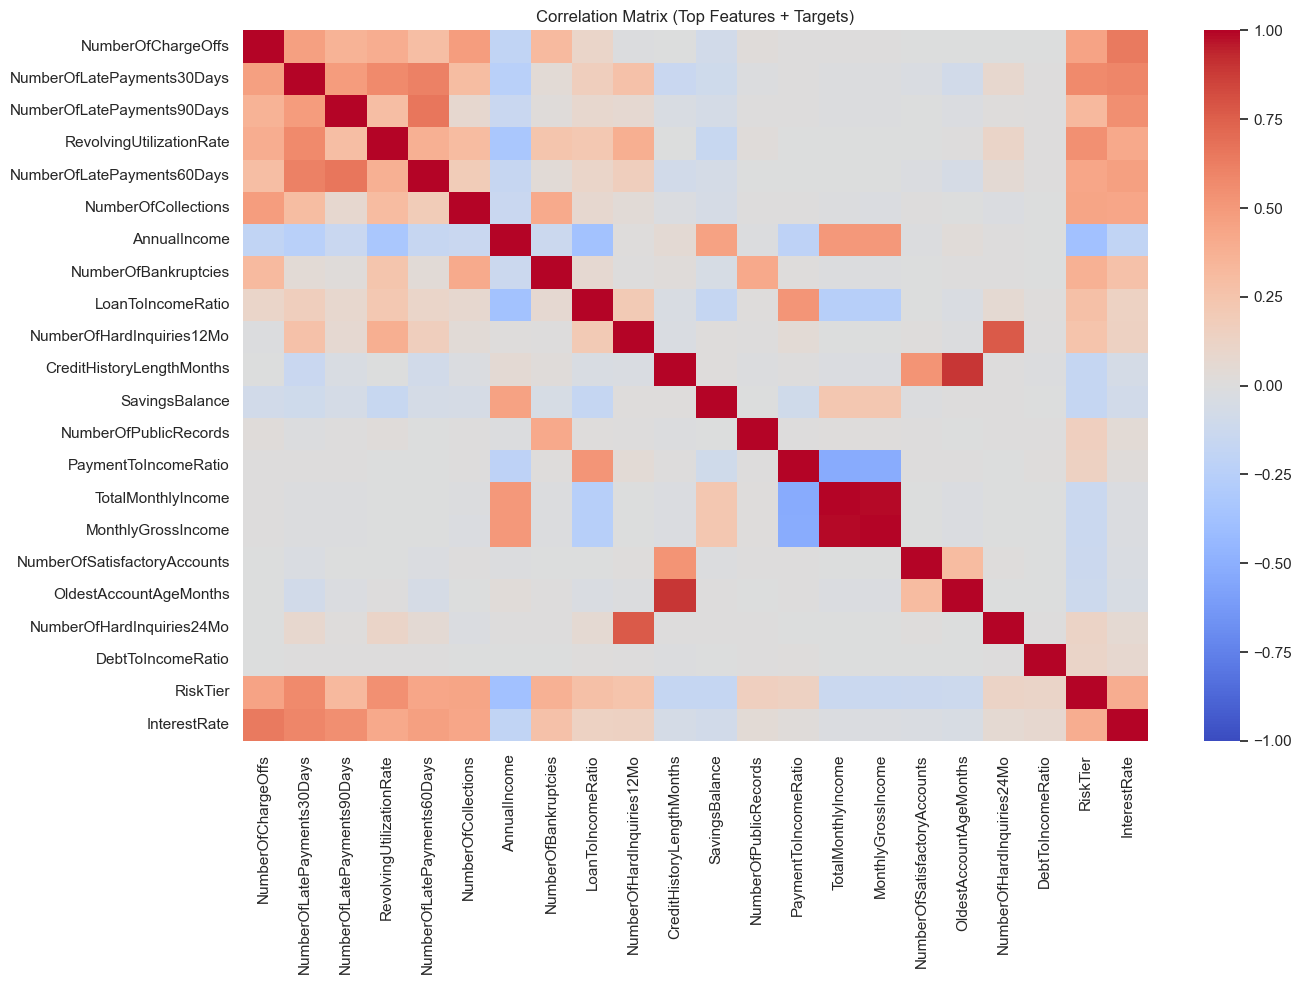

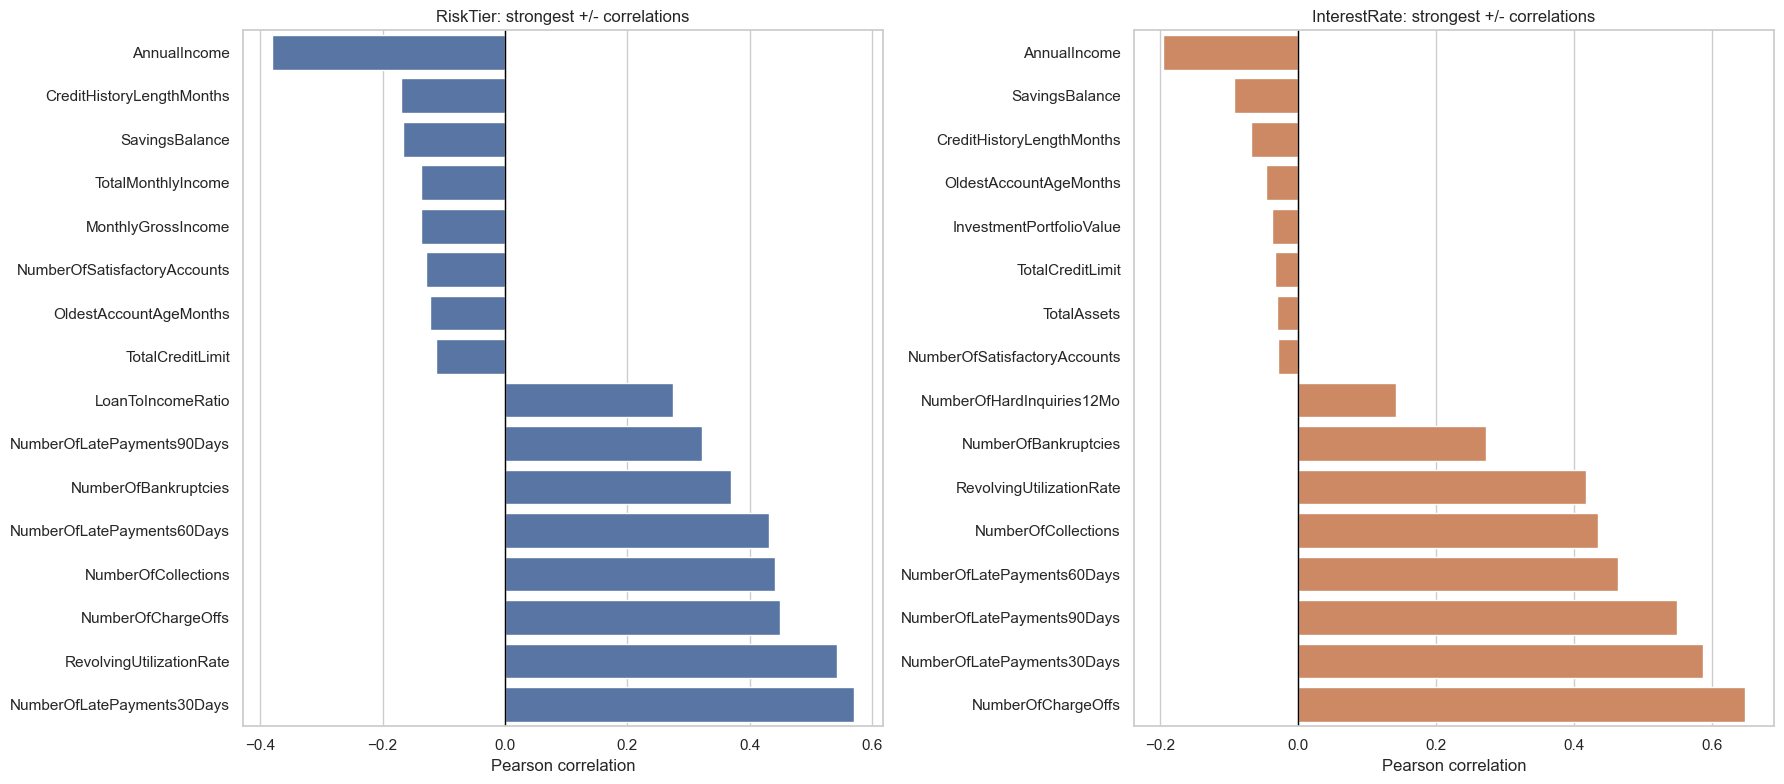

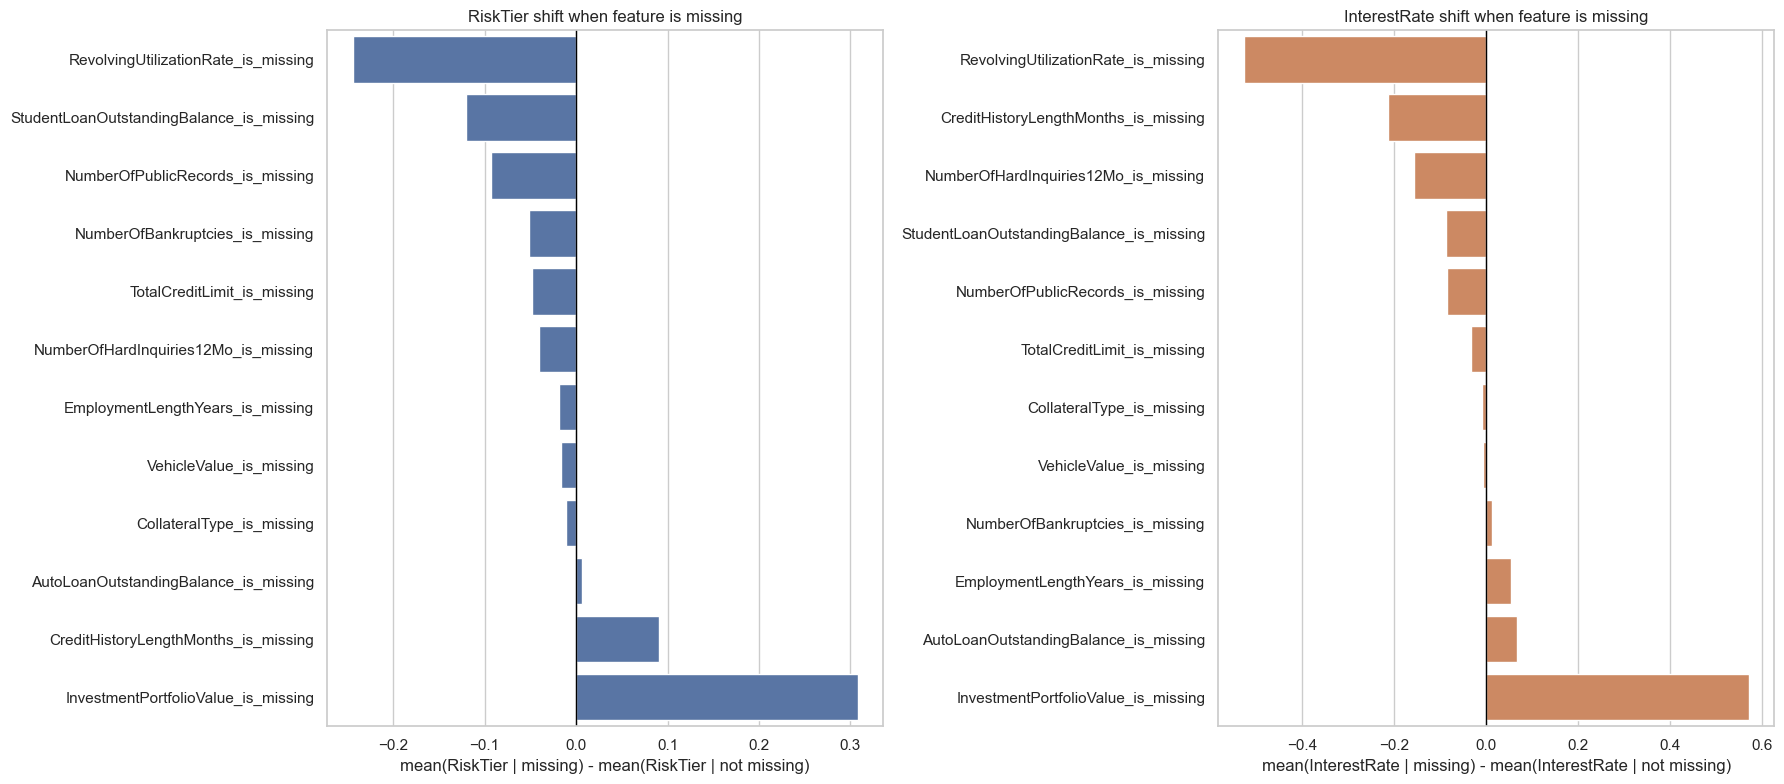

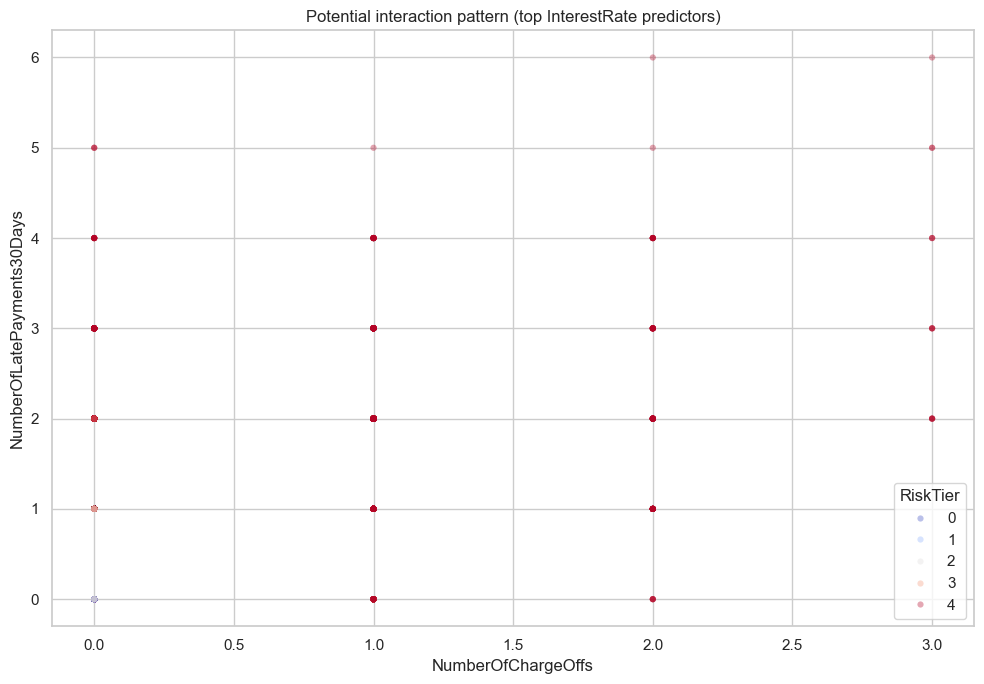

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

eda_df = X_processed.copy()
eda_df['RiskTier'] = y_cls.values
eda_df['InterestRate'] = y_reg.values

corr = eda_df.corr(numeric_only=True)
feature_corr = corr[['RiskTier', 'InterestRate']].drop(
    index=['RiskTier', 'InterestRate'],
    errors='ignore'
)

# 1) Correlation matrix of the most target-relevant features
n_top = min(20, len(feature_corr))
top_features = feature_corr.abs().max(axis=1).sort_values(ascending=False).head(n_top).index.tolist()
heatmap_cols = top_features + ['RiskTier', 'InterestRate']

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr.loc[heatmap_cols, heatmap_cols],
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=False
)
plt.title('Correlation Matrix (Top Features + Targets)')
plt.tight_layout()
plt.show()

# 2) Strongest positive/negative correlations for each target
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, target, color in zip(
    axes,
    ['RiskTier', 'InterestRate'],
    ['#4C72B0', '#DD8452']
):
    target_corr = feature_corr[target].dropna()
    strongest = pd.concat([
        target_corr.nsmallest(8),
        target_corr.nlargest(8)
    ]).drop_duplicates().sort_values()

    sns.barplot(x=strongest.values, y=strongest.index, ax=ax, color=color)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'{target}: strongest +/- correlations')
    ax.set_xlabel('Pearson correlation')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

# 3) Missingness impact plots (using new *_is_missing indicators)
indicator_cols = [c for c in X_processed.columns if c.endswith('_is_missing')]
if indicator_cols:
    missing_effects = []
    for c in indicator_cols:
        miss_mask = X_processed[c] == 1
        miss_rate = miss_mask.mean()

        if miss_rate in (0, 1):
            continue

        risk_delta = y_cls.loc[miss_mask].mean() - y_cls.loc[~miss_mask].mean()
        rate_delta = y_reg.loc[miss_mask].mean() - y_reg.loc[~miss_mask].mean()

        missing_effects.append({
            'indicator': c,
            'missing_rate': miss_rate,
            'risk_delta': risk_delta,
            'interest_delta': rate_delta
        })

    missing_effects = pd.DataFrame(missing_effects)

    if not missing_effects.empty:
        top_missing = (
            missing_effects
            .assign(score=lambda d: d['risk_delta'].abs() + d['interest_delta'].abs())
            .nlargest(12, 'score')
        )

        fig, axes = plt.subplots(1, 2, figsize=(18, 8))

        sns.barplot(
            data=top_missing.sort_values('risk_delta'),
            x='risk_delta',
            y='indicator',
            ax=axes[0],
            color='#4C72B0'
        )
        axes[0].axvline(0, color='black', linewidth=1)
        axes[0].set_title('RiskTier shift when feature is missing')
        axes[0].set_xlabel('mean(RiskTier | missing) - mean(RiskTier | not missing)')
        axes[0].set_ylabel('')

        sns.barplot(
            data=top_missing.sort_values('interest_delta'),
            x='interest_delta',
            y='indicator',
            ax=axes[1],
            color='#DD8452'
        )
        axes[1].axvline(0, color='black', linewidth=1)
        axes[1].set_title('InterestRate shift when feature is missing')
        axes[1].set_xlabel('mean(InterestRate | missing) - mean(InterestRate | not missing)')
        axes[1].set_ylabel('')

        plt.tight_layout()
        plt.show()
    else:
        print('Missing indicators exist, but no usable split found for target comparison.')
else:
    print('No *_is_missing indicator columns were found.')

# 4) Interaction view: top two InterestRate-correlated features
interest_candidates = feature_corr['InterestRate'].abs().sort_values(ascending=False).index.tolist()
interaction_features = [c for c in interest_candidates if not c.endswith('_is_missing')][:2]

if len(interaction_features) == 2:
    plot_df = eda_df[[interaction_features[0], interaction_features[1], 'RiskTier']].copy()
    plot_df = plot_df.sample(n=min(8000, len(plot_df)), random_state=42)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=plot_df,
        x=interaction_features[0],
        y=interaction_features[1],
        hue='RiskTier',
        palette='coolwarm',
        alpha=0.35,
        s=20,
        linewidth=0
    )
    plt.title('Potential interaction pattern (top InterestRate predictors)')
    plt.tight_layout()
    plt.show()


In [6]:
class LinearStackedRiskTier:
    """
    Base learners: RandomForest + XGBoost + LightGBM
    Meta learner: LinearRegression over concatenated class probabilities.
    """
    def __init__(self, base_models, n_splits=5, random_state=42):
        self.base_models = base_models
        self.n_splits = n_splits
        self.random_state = random_state
        self.meta_model = LinearRegression()
        self.fitted_models_ = {}
        self.classes_ = None
        self.oof_pred_ = None

    def _to_class_labels(self, raw_pred):
        return np.clip(np.rint(raw_pred), self.classes_.min(), self.classes_.max()).astype(int)

    def fit(self, X, y):
        X = X.reset_index(drop=True)
        y = y.reset_index(drop=True)

        self.classes_ = np.sort(y.unique())
        n_classes = len(self.classes_)
        n_models = len(self.base_models)

        oof_meta = np.zeros((len(X), n_models * n_classes), dtype=float)
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)

        for model_idx, (name, model) in enumerate(self.base_models.items()):
            start = model_idx * n_classes
            end = start + n_classes

            for tr_idx, va_idx in skf.split(X, y):
                fold_model = clone(model)
                fold_model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
                oof_meta[va_idx, start:end] = fold_model.predict_proba(X.iloc[va_idx])

            final_model = clone(model)
            final_model.fit(X, y)
            self.fitted_models_[name] = final_model

        self.meta_model.fit(oof_meta, y)
        self.oof_pred_ = self._to_class_labels(self.meta_model.predict(oof_meta))
        return self

    def _meta_features(self, X):
        proba_blocks = [model.predict_proba(X) for model in self.fitted_models_.values()]
        return np.hstack(proba_blocks)

    def predict(self, X):
        raw_pred = self.meta_model.predict(self._meta_features(X))
        return self._to_class_labels(raw_pred)


def build_task_a_base_models():
    return {
        'rf': RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1
        ),
        'xgb': XGBClassifier(
            objective='multi:softprob',
            num_class=5,
            n_estimators=350,
            learning_rate=0.05011952008381389,
            max_depth=6,
            subsample=0.8996473404798764,
            colsample_bytree=0.8001695969176756,
            eval_metric='mlogloss',
            tree_method='hist',
            random_state=42,
            n_jobs=-1
        ),
        'lgbm': LGBMClassifier(
            objective='multiclass',
            num_class=5,
            n_estimators=350,
            learning_rate=0.0500574425921408,
            num_leaves=31,
            subsample=0.8998304030823245,
            colsample_bytree=0.7998642491270678,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )
    }


X_train_raw, X_val_raw, y_train_cls, y_val_cls, y_train_reg, y_val_reg = train_test_split(
    X, y_cls, y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print(f"Train raw: {X_train_raw.shape} | Val raw: {X_val_raw.shape}")

baseline_task_a_prep = fit_task_a_baseline_preprocessor(X_train_raw)
X_train_task_a_baseline = transform_task_a_baseline(X_train_raw, baseline_task_a_prep)
X_val_task_a_baseline = transform_task_a_baseline(X_val_raw, baseline_task_a_prep)

task_a_prep = fit_task_a_preprocessor(X_train_raw)
X_train_task_a = transform_task_a(X_train_raw, task_a_prep)
X_val_task_a = transform_task_a(X_val_raw, task_a_prep)

task_b_prep = fit_task_b_preprocessor(X_train_raw)
X_train_task_b = transform_task_b(X_train_raw, task_b_prep)
X_val_task_b = transform_task_b(X_val_raw, task_b_prep)

task_a_no_missing = bool(X_train_task_a.isnull().sum().sum() == 0 and X_val_task_a.isnull().sum().sum() == 0)
task_a_schema_ok = bool(X_train_task_a.columns.equals(X_val_task_a.columns))
task_b_schema_ok = bool(X_train_task_b.columns.equals(X_val_task_b.columns))

print(f"Baseline Task A matrix: {X_train_task_a_baseline.shape} -> {X_val_task_a_baseline.shape}")
print(f"Upgraded Task A matrix: {X_train_task_a.shape} -> {X_val_task_a.shape}")
print(f"Task B matrix:          {X_train_task_b.shape} -> {X_val_task_b.shape}")
print(f"Task A checks — no missing: {task_a_no_missing} | schema aligned: {task_a_schema_ok}")
print(f"Task B check  — schema aligned: {task_b_schema_ok}")

assert task_a_no_missing, 'transform_task_a left missing values behind.'
assert task_a_schema_ok, 'Task A train/validation schemas do not match.'
assert task_b_schema_ok, 'Task B train/validation schemas do not match.'

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train_task_b)
X_va_sc = scaler.transform(X_val_task_b)

baseline_clf = LinearStackedRiskTier(base_models=build_task_a_base_models(), n_splits=5, random_state=42)
baseline_clf.fit(X_train_task_a_baseline, y_train_cls)

clf = LinearStackedRiskTier(base_models=build_task_a_base_models(), n_splits=5, random_state=42)
clf.fit(X_train_task_a, y_train_cls)


Train raw: (28000, 55) | Val raw: (7000, 55)
Baseline Task A matrix: (28000, 71) -> (7000, 71)
Upgraded Task A matrix: (28000, 115) -> (7000, 115)
Task B matrix:          (28000, 115) -> (7000, 115)
Task A checks — no missing: True | schema aligned: True
Task B check  — schema aligned: True


In [7]:
print("=" * 55)
print("TASK A: RiskTier Classification — Baseline vs Upgraded")
print("=" * 55)

baseline_pred_train_cls = baseline_clf.oof_pred_
baseline_pred_cls = baseline_clf.predict(X_val_task_a_baseline)

y_pred_train_cls = clf.oof_pred_
y_pred_cls = clf.predict(X_val_task_a)

task_a_comparison = pd.DataFrame([
    {
        'Model': 'Leakage-free baseline',
        'Train Accuracy (OOF)': accuracy_score(y_train_cls, baseline_pred_train_cls),
        'Val Accuracy': accuracy_score(y_val_cls, baseline_pred_cls),
        'Val Macro F1': f1_score(y_val_cls, baseline_pred_cls, average='macro'),
    },
    {
        'Model': 'Upgraded one-hot + clipping',
        'Train Accuracy (OOF)': accuracy_score(y_train_cls, y_pred_train_cls),
        'Val Accuracy': accuracy_score(y_val_cls, y_pred_cls),
        'Val Macro F1': f1_score(y_val_cls, y_pred_cls, average='macro'),
    },
]).set_index('Model')

print(task_a_comparison.round(4).to_string())
print()
print(f"Task A checks: no missing={task_a_no_missing}, val schema match={task_a_schema_ok}")
print()
print("Baseline Classification Report:")
print(classification_report(
    y_val_cls, baseline_pred_cls,
    labels=[0, 1, 2, 3, 4],
    target_names=['VeryLow(0)', 'Low(1)', 'Moderate(2)', 'High(3)', 'VeryHigh(4)']
))
print("Upgraded Classification Report:")
print(classification_report(
    y_val_cls, y_pred_cls,
    labels=[0, 1, 2, 3, 4],
    target_names=['VeryLow(0)', 'Low(1)', 'Moderate(2)', 'High(3)', 'VeryHigh(4)']
))


TASK A: RiskTier Classification — Baseline vs Upgraded
                             Train Accuracy (OOF)  Val Accuracy  Val Macro F1
Model                                                                        
Leakage-free baseline                      0.8109        0.8107        0.8124
Upgraded one-hot + clipping                0.8093        0.8120        0.8137

Task A checks: no missing=True, val schema match=True

Baseline Classification Report:
              precision    recall  f1-score   support

  VeryLow(0)       0.86      0.78      0.82      1345
      Low(1)       0.68      0.78      0.73      1456
 Moderate(2)       0.77      0.72      0.75      1400
     High(3)       0.81      0.85      0.83      1362
 VeryHigh(4)       0.97      0.92      0.94      1437

    accuracy                           0.81      7000
   macro avg       0.82      0.81      0.81      7000
weighted avg       0.82      0.81      0.81      7000

Upgraded Classification Report:
              precision 

In [8]:
print("=" * 55)
print("TASK B: InterestRate Regression — Linear Regression")
print("=" * 55)

reg = LinearRegression()
reg.fit(X_tr_sc, y_train_reg)

y_pred_reg = reg.predict(X_va_sc)
val_r2     = r2_score(y_val_reg, y_pred_reg)
val_rmse   = mean_squared_error(y_val_reg, y_pred_reg) ** 0.5

print(f"Train R²:  {r2_score(y_train_reg, reg.predict(X_tr_sc)):.4f}")
print(f"Val   R²:  {val_r2:.4f}")
print(f"Val RMSE:  {val_rmse:.4f}%")
print(f"Val MAE:   {np.mean(np.abs(y_val_reg - y_pred_reg)):.4f}%")

# TODO: Try RandomForestRegressor, XGBRegressor


TASK B: InterestRate Regression — Linear Regression
Train R²:  0.6221
Val   R²:  0.6243
Val RMSE:  2.6437%
Val MAE:   1.7263%


In [9]:
test = pd.read_csv('creditsense-ai1215/credit_test.csv')

X_test_task_a = transform_task_a(test, task_a_prep)
X_test_task_b = transform_task_b(test, task_b_prep)
X_test_task_b_scaled = scaler.transform(X_test_task_b)

task_a_test_schema_ok = bool(X_test_task_a.columns.equals(X_train_task_a.columns))
task_b_test_schema_ok = bool(X_test_task_b.columns.equals(X_train_task_b.columns))

assert task_a_test_schema_ok, 'Task A test schema does not match training features.'
assert task_b_test_schema_ok, 'Task B test schema does not match training features.'

pred_cls = clf.predict(X_test_task_a)
pred_reg = np.clip(reg.predict(X_test_task_b_scaled), 4.99, 35.99).round(2)

submission = pd.DataFrame({
    'Id':           range(len(pred_cls)),
    'RiskTier':     pred_cls,
    'InterestRate': pred_reg,
})
submission.to_csv('submission.csv', index=False)

print(f"Task A unscaled test matrix: {X_test_task_a.shape}")
print(f"Task B scaled test matrix:   {X_test_task_b_scaled.shape}")
print(f"Schema checks — Task A: {task_a_test_schema_ok} | Task B: {task_b_test_schema_ok}")
print("Saved submission.csv")
print()
print("Preview:")
print(submission.head(10).to_string(index=False))
print()
print("RiskTier counts:")
print(pd.Series(pred_cls).value_counts().sort_index())
print()
print("InterestRate summary:")
print(pd.Series(pred_reg).describe().round(2))


Task A unscaled test matrix: (15000, 115)
Task B scaled test matrix:   (15000, 115)
Schema checks — Task A: True | Task B: True
Saved submission.csv

Preview:
 Id  RiskTier  InterestRate
  0         2          5.80
  1         0          6.18
  2         2          6.53
  3         3          6.93
  4         4         17.63
  5         3          6.43
  6         2          6.30
  7         1          5.70
  8         2          6.27
  9         2          5.60

RiskTier counts:
0    2627
1    3587
2    2750
3    3151
4    2885
Name: count, dtype: int64

InterestRate summary:
count    15000.00
mean         7.36
std          3.39
min          4.99
25%          5.54
50%          6.11
75%          7.38
max         35.99
dtype: float64
